# Klasifikasi Kesegaran Buah Menggunakan Metode GLCM dan Random Forest
## Percobaan 4 — Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening + Morfologi Closing (6 Preprocessing)
### Nama Anggota
- Thoriq Abdillah Falian Kusuma : F1D02410098
- Jasmine Aulia Santoso : F1D02410010
- Ulul Asmi : F1D002410144
- Fatriya Annastha Putra : F1D02410046

## Import Library

Cell dibawah mengimpor seluruh library yang dibutuhkan sepanjang program.

Library `os` digunakan untuk melakukan navigasi sistem file, sehingga program dapat membaca folder dataset dan melakukan iterasi secara otomatis pada setiap subfolder kelas. `OpenCV (cv2)` digunakan untuk membaca citra dari media penyimpanan, melakukan konversi warna dari BGR ke grayscale, serta mengubah ukuran citra (resize) agar memiliki dimensi yang seragam. Untuk keperluan visualisasi, `Matplotlib (matplotlib.pyplot)` digunakan untuk menampilkan sampel citra, grafik distribusi data, dan confusion matrix.

Dalam pengolahan data numerik, `NumPy` digunakan untuk melakukan operasi pada array multidimensi yang berfungsi menyimpan data citra, label, serta hasil perhitungan fitur. `Pandas` digunakan untuk mengelola data hasil ekstraksi fitur dalam bentuk DataFrame serta menyimpan dan membaca data dalam format CSV. Pembagian dataset menjadi data latih dan data uji dilakukan menggunakan fungsi `train_test_split` dari library `scikit-learn`, sehingga proses pembagian data dapat dilakukan secara acak namun tetap dapat direproduksi.

Pada tahap ekstraksi fitur tekstur, digunakan fungsi `graycomatrix` dan `graycoprops` dari library `scikit-image` untuk membentuk Gray-Level Co-occurrence Matrix (GLCM) dan menghitung berbagai karakteristik tekstur seperti contrast, correlation, energy, dan homogeneity. Selain itu, fungsi `entrop` dari library `SciPy` digunakan untuk menghitung nilai entropi berdasarkan distribusi probabilitas pada matriks GLCM sebagai fitur tambahan yang merepresentasikan kompleksitas tekstur citra.

Tahap klasifikasi dilakukan menggunakan tiga algoritma pembelajaran mesin dari library scikit-learn, yaitu RandomForestClassifier sebagai metode klasifikasi berbasis ensemble pohon keputusan, SVC (Support Vector Classifier) sebagai implementasi algoritma Support Vector Machine (SVM) dengan kernel Radial Basis Function (RBF), serta KNeighborsClassifier yang menerapkan metode K-Nearest Neighbors (KNN). Evaluasi performa model dilakukan menggunakan berbagai metrik dari sklearn.metrics, meliputi accuracy, precision, recall, F1-score, classification report, dan confusion matrix. Selanjutnya, Seaborn digunakan untuk menghasilkan visualisasi statistik tingkat lanjut, khususnya dalam menampilkan heatmap correlation matrix yang digunakan untuk menganalisis hubungan antar fitur yang diekstraksi.


In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

### Data Loading

Cell ini membaca seluruh gambar dari folder dataset dan melakukan resize seragam ke 250×250 piksel.

Yang dilakukan:


Fungsi resize_image(image, target_size=(250, 250)) didefinisikan sebagai wrapper modular untuk cv.resize()
Iterasi setiap subfolder dalam direktori Dataset/ masing-masing subfolder mewakili satu kelas
Setiap gambar dibaca, di-resize ke 250×250 piksel, dan dikonversi ke np.uint8
Gambar, label, dan nama file disimpan ke list masing-masing lalu dikonversi ke numpy array
Output: Total data: 828 dan Labels: ['Fresh_Apple' 'Moderately_Fresh_Apple' 'Rotten_Apple']


Ukuran resize 250×250 piksel konsisten dengan Percobaan 1, 2, dan 3, memastikan dimensi seragam sebagai syarat pemrosesan batch dan komputasi GLCM yang efisien.

In [2]:
def resize_image(image, target_size=(250, 250)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Dataset'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (250, 250))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 828
Labels: ['Fresh_Apple' 'Moderately_Fresh_Apple' 'Rotten_Apple']


## Data Understanding

Cell ini menampilkan distribusi jumlah gambar per kelas menggunakan bar chart.

Distribusi Dataset:

Fresh_Apple berjumlah 507 gambar dengan proporsi ±61.2%. 
Moderately_Fresh_Apple berjumlah 166 gambar dengan proporsi ±20.0%. 
Rotten_Apple berjumlah 155 gambar dengan proporsi ±18.7%.
Total berjumlah 828 gambar dengan proporsi 100%.

Dataset identik dengan percobaan-percobaan sebelumnya. Distribusi tidak seimbang dengan Fresh_Apple mendominasi (~3× lebih banyak dari kelas lain) tetap menjadi karakteristik yang relevan dalam interpretasi hasil evaluasi model.

Karakteristik visual gambar:

Gambar diambil dengan kamera smartphone dalam kondisi pencahayaan dan background bervariasi.
Apel segar: permukaan mulus, tekstur seragam, warna merah/hijau cerah.
Apel cukup segar: mulai ada bercak kecil dan perubahan warna lokal.
Apel busuk: permukaan tidak merata, bercak coklat/hitam signifikan, tekstur kasar.

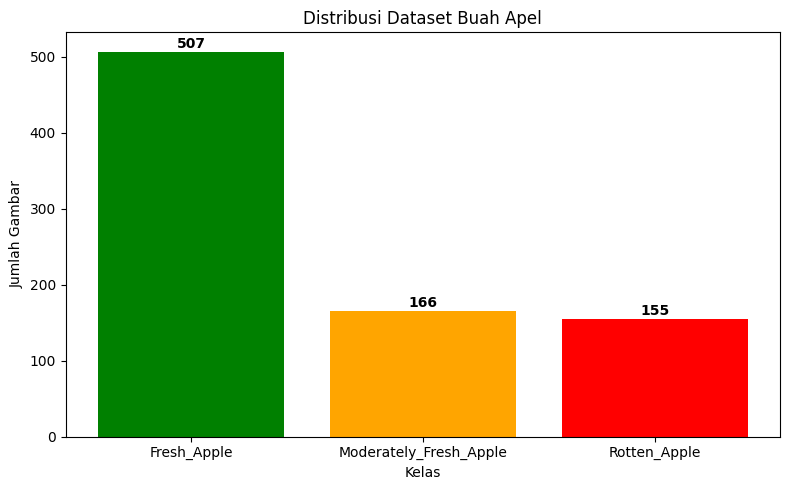

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['green', 'orange', 'red'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Buah Apel')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Sample Data

Cell ini menggunakan fungsi show_sample_images() untuk menampilkan contoh gambar original dari setiap kelas dalam format grid 3×3.

Yang dilakukan:

Fungsi menerima array gambar, label, nama kelas, judul, dan jumlah sampel (n=3).
Grid 3 baris × 3 kolom = 9 gambar total, gambar BGR dikonversi ke RGB sebelum ditampilkan.
Dipanggil dengan judul 'Sample Data Original' untuk membedakan dari visualisasi di tahap preprocessing berikutnya.


Tujuan: Memverifikasi data terbaca benar, warna natural, dan label sesuai konten. Fungsi ini bersifat reusable dan dipanggil kembali setelah setiap tahap preprocessing untuk memperlihatkan transformasi visual yang terjadi.

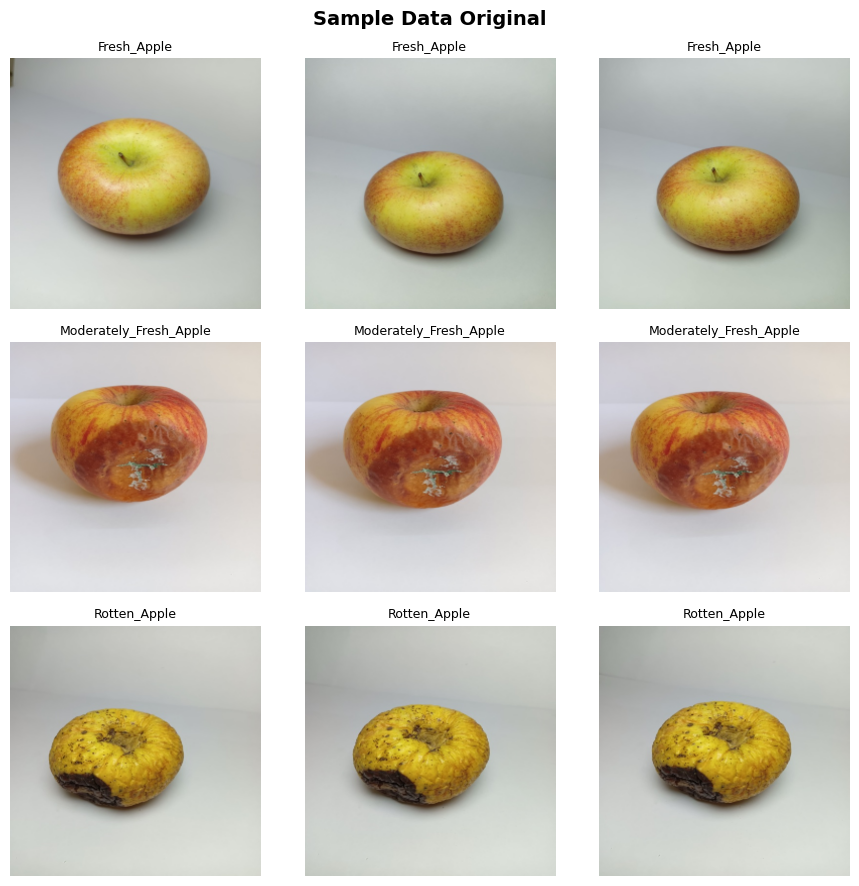

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Grayscale

Cell ini mengkonversi seluruh gambar dari BGR (3-channel) ke Grayscale (1-channel) menggunakan cv.cvtColor(img, cv.COLOR_BGR2GRAY).

Yang dilakukan:

Iterasi setiap gambar dalam data, konversi ke grayscale, simpan ke list img_grey
Hasil divisualisasikan dengan show_sample_images(img_grey, ..., 'Grayscale Images')


Grayscale dilakukan sebagai prasyarat wajib untuk seluruh preprocessing dan GLCM berikutnya, yaitu Sobel, Histogram Equalization, dan GLCM semuanya bekerja pada data intensitas tunggal (0–255). Formula pembobotan Y = 0.114B + 0.587G + 0.299R mempertahankan persepsi kecerahan yang akurat.

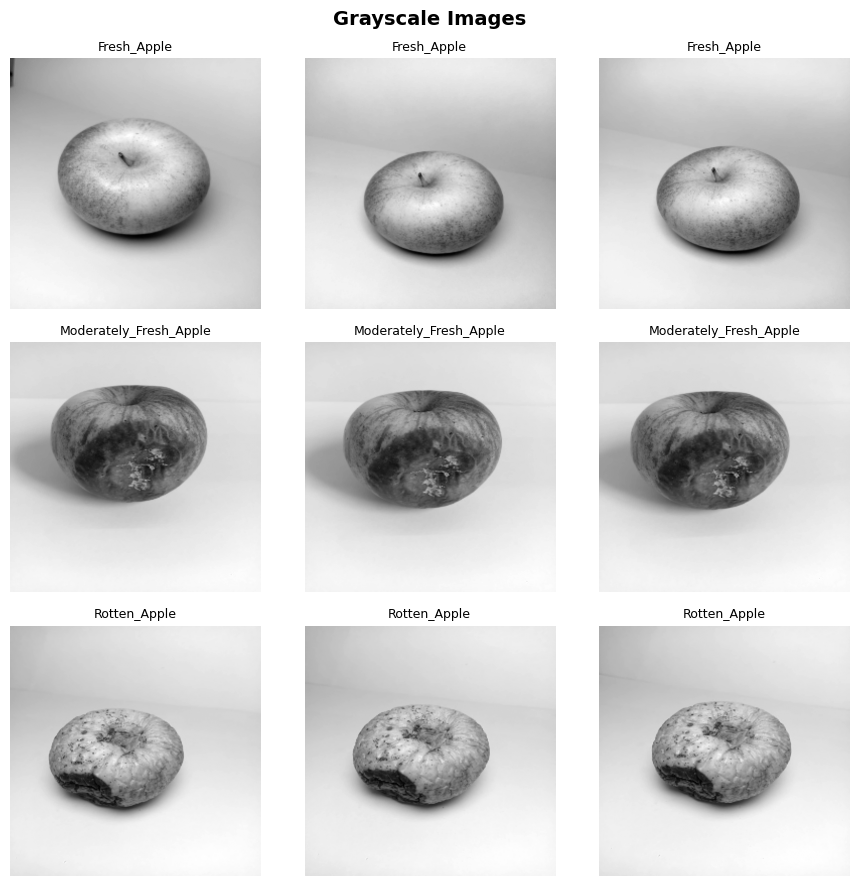

In [5]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

## Preprocessing 4: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening + Morfologi Closing
Pada percobaan 4, digunakan 6 preprocessing (terlengkap):
1. **Resize** (sudah dilakukan saat data loading ke ukuran 250x250)
2. **Median Filter** — menghilangkan noise salt & pepper
3. **Histogram Equalization** — meningkatkan kontras gambar
4. **Sobel Edge Detection** — mendeteksi tepi/batas area busuk pada apel
5. **Sharpening** — mempertegas detail tekstur permukaan buah
6. **Morfologi Closing** — menutup lubang kecil dan merapikan area pada permukaan apel

### Step 1: Median Filter

Cell ini menerapkan Median Filter manual dengan kernel 3×3 pada seluruh gambar grayscale. Fungsi hitung_median(image) menghitung nilai median dari sebuah array, sedangkan fungsi median_filter(image, kernel_size=3) mengimplementasikan sliding window 3×3 yang digeser ke setiap posisi piksel. Setiap piksel output diisi dengan nilai median dari 9 piksel dalam window tersebut. Gambar di-pad menggunakan np.pad(..., mode='reflect') agar piksel tepi tetap dapat diproses. Hasil 828 gambar disimpan dalam array img_median dan divisualisasikan dengan judul 'Hasil Median Filter'.

Median Filter menghilangkan noise salt-and-pepper dari sensor kamera secara efektif sambil mempertahankan tepi objek karena nilai median tidak terpengaruh outlier. Dalam konteks pipeline Percobaan 4, Median Filter adalah lapisan pertama kebersihan sinyal yang memastikan Histogram Equalization tidak memperkuat noise dan Sobel tidak mendeteksi tepi palsu akibat noise. Implementasi manual tanpa fungsi OpenCV tingkat tinggi menunjukkan pemahaman algoritmik terhadap cara kerja filter.

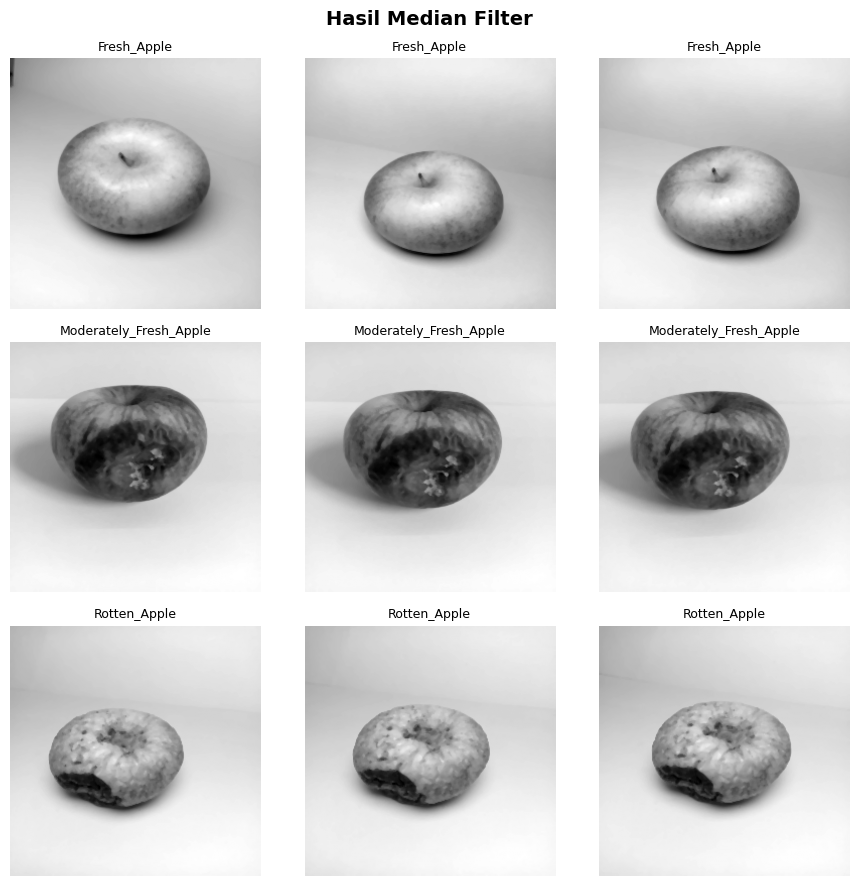

In [6]:
def hitung_median(image):
    return np.median(image)

def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = hitung_median(window)
    return result.astype(np.uint8)

img_median = []
for img in img_grey:
    filtered = median_filter(img, kernel_size=3)
    img_median.append(filtered)
img_median = np.array(img_median)

show_sample_images(img_median, labels, class_names, 'Hasil Median Filter')

### Step 2: Histogram Equalization

Cell ini menerapkan Histogram Equalization manual pada hasil Median Filter. Fungsi histogram_equalization(image) bekerja melalui lima langkah: menghitung histogram intensitas menggunakan np.histogram dengan 256 bins, menghitung Cumulative Distribution Function (CDF) dari histogram, melakukan masking nilai CDF=0 menggunakan np.ma.masked_equal untuk menghindari pembagian nol, menerapkan linear stretching (cdf - min) * 255 / (max - min) untuk menghasilkan lookup table dalam rentang 0 hingga 255, dan memetakan setiap piksel gambar melalui lookup table tersebut. Hasil disimpan dalam img_histeq dan divisualisasikan.

Histogram Equalization meratakan distribusi intensitas ke rentang penuh 0 hingga 255, sehingga perbedaan antara area sehat dan area busuk pada permukaan apel menjadi lebih kontras dan lebih mudah dibedakan. Nilai Contrast GLCM rata-rata meningkat dari ~27,2 (Percobaan 2 berhenti di HE) menjadi ~28,7 pada Percobaan 4, menunjukkan bahwa HE dalam pipeline panjang menghasilkan nilai yang sedikit lebih tinggi. Dalam konteks pipeline 6-tahap ini, HE berperan sebagai jembatan yang memperkuat sinyal sebelum Sobel bekerja — kontras lebih tinggi menghasilkan gradien tepi yang lebih kuat dan lebih representatif antar kelas.

Pengaruh terhadap citra dan akurasi: Pada Percobaan 2 di mana HE berdiri sendiri sebagai preprocessing terakhir, akurasi justru turun dari Percobaan 1 untuk semua model. Namun pada Percobaan 4 dan 3 di mana HE diikuti oleh Sobel, kontribusinya menjadi positif karena gradien intensitas yang lebih kuat mempertegas peta tepi yang dihasilkan operator Sobel, memberikan fitur GLCM yang lebih diskriminatif untuk membedakan tingkat kesegaran apel.

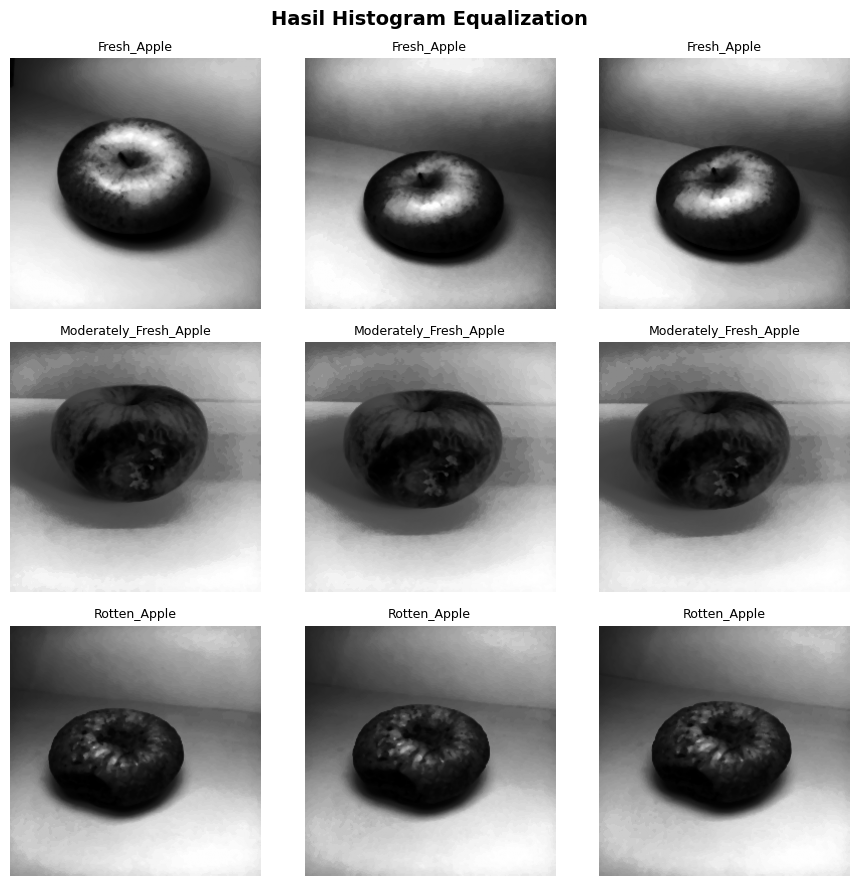

In [7]:
def histogram_equalization(image):
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[image]

img_histeq = []
for img in img_median:
    equalized = histogram_equalization(img)
    img_histeq.append(equalized)
img_histeq = np.array(img_histeq)

show_sample_images(img_histeq, labels, class_names, 'Hasil Histogram Equalization')

### Step 3: Sobel Edge Detection

Cell ini menerapkan deteksi tepi Sobel manual menggunakan konvolusi kernel 3×3. Dua kernel Sobel didefinisikan secara eksplisit: kernel horizontal Sx dengan nilai [-1,0,1; -2,0,2; -1,0,1] untuk mendeteksi tepi vertikal, dan kernel vertikal Sy dengan nilai [-1,-2,-1; 0,0,0; 1,2,1] untuk mendeteksi tepi horizontal. Fungsi convo_edge(image, kernel) mengimplementasikan konvolusi manual dengan padding reflektif yang menghasilkan peta gradien dalam satu arah. Fungsi deteksi_tepi(image, Sx, Sy) menghitung Gx menggunakan convo_edge dengan Sx, menghitung Gy menggunakan convo_edge dengan Sy, menghitung magnitude gradien total dengan rumus √(Gx² + Gy²), melakukan np.clip(magnitude, 0, 255), dan mengembalikan gambar uint8. Hasil disimpan dalam img_sobel dan divisualisasikan.

Pengaruh terhadap citra dan akurasi: Sobel mengubah representasi gambar apel dari peta intensitas warna menjadi peta kerapatan tepi. Area apel busuk dengan banyak batas antara jaringan sehat dan rusak menghasilkan gambar Sobel dengan jaringan tepi padat, sementara area apel segar menghasilkan gambar Sobel dengan sedikit tepi dan dominasi piksel bernilai mendekati nol. Perbedaan karakter inilah yang menjadikan fitur GLCM pasca-Sobel jauh lebih diskriminatif. Nilai Correlation turun dari ~0,998 (Percobaan 1 dan 2) ke ~0,793 (Percobaan 4) karena transisi abrupt antara piksel tepi tinggi dan area datar mendekati nol merusak korelasi spasial. Justru perubahan nilai Correlation inilah yang meningkatkan daya pembeda antar kelas, berkontribusi pada lonjakan akurasi dibanding Percobaan 1 dan 2.

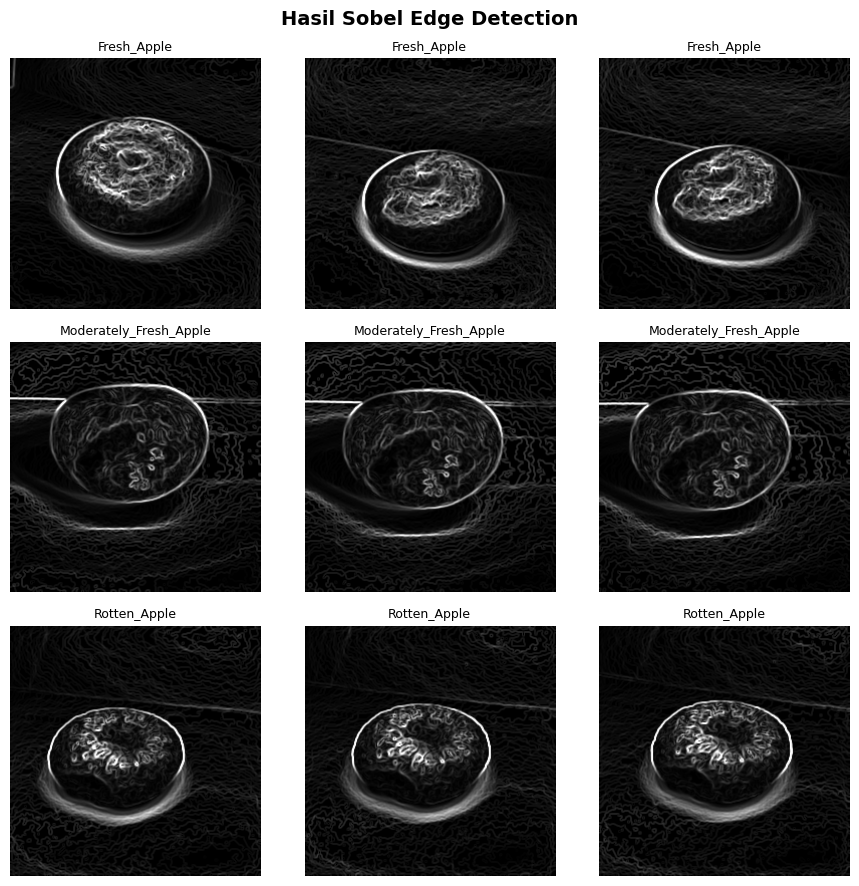

In [8]:
# Kernel Sobel
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])

Sy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]])

def convo_edge(image, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            result[i, j] = np.sum(window * kernel)
    return result

def deteksi_tepi(image, Sx, Sy):
    Gx = convo_edge(image.astype(np.float64), Sx)
    Gy = convo_edge(image.astype(np.float64), Sy)
    magnitude = np.sqrt(Gx**2 + Gy**2)
    magnitude = np.clip(magnitude, 0, 255)
    return magnitude.astype(np.uint8)

img_sobel = []
for img in img_histeq:
    sobel = deteksi_tepi(img, Sx, Sy)
    img_sobel.append(sobel)
img_sobel = np.array(img_sobel)

show_sample_images(img_sobel, labels, class_names, 'Hasil Sobel Edge Detection')

### Step 4: Sharpening

Cell ini menerapkan filter sharpening pada hasil Sobel menggunakan cv.filter2D. Fungsi sharpen_image(image) mendefinisikan kernel Laplacian-based berukuran 3×3 dengan nilai pusat 8/9 dan delapan tetangga masing-masing bernilai -1/9, sehingga jumlah seluruh elemen kernel sama dengan nol. cv.filter2D(image, -1, kernel) melakukan konvolusi, diikuti np.clip(sharpened, 0, 255).astype(np.uint8) untuk pembatasan rentang nilai. Hasil disimpan dalam img_sharpened dan divisualisasikan.

Karena jumlah elemen kernel sama dengan nol, area datar dengan intensitas seragam tidak berubah setelah sharpening diterapkan. Hanya area dengan perbedaan intensitas, yaitu garis-garis tepi hasil Sobel yang menjadi lebih tegas dan lebih kontras. Ini mempertegas batas tepi yang sudah terdeteksi Sobel sehingga distribusi GLCM menjadi lebih terpolarisasi dan lebih konsisten per kelas. Kontribusi Sharpening dalam pipeline ini bersifat pelengkap, ia mempertegas sinyal yang sudah dibentuk Sobel sebelum masuk ke tahap Morfologi Closing.

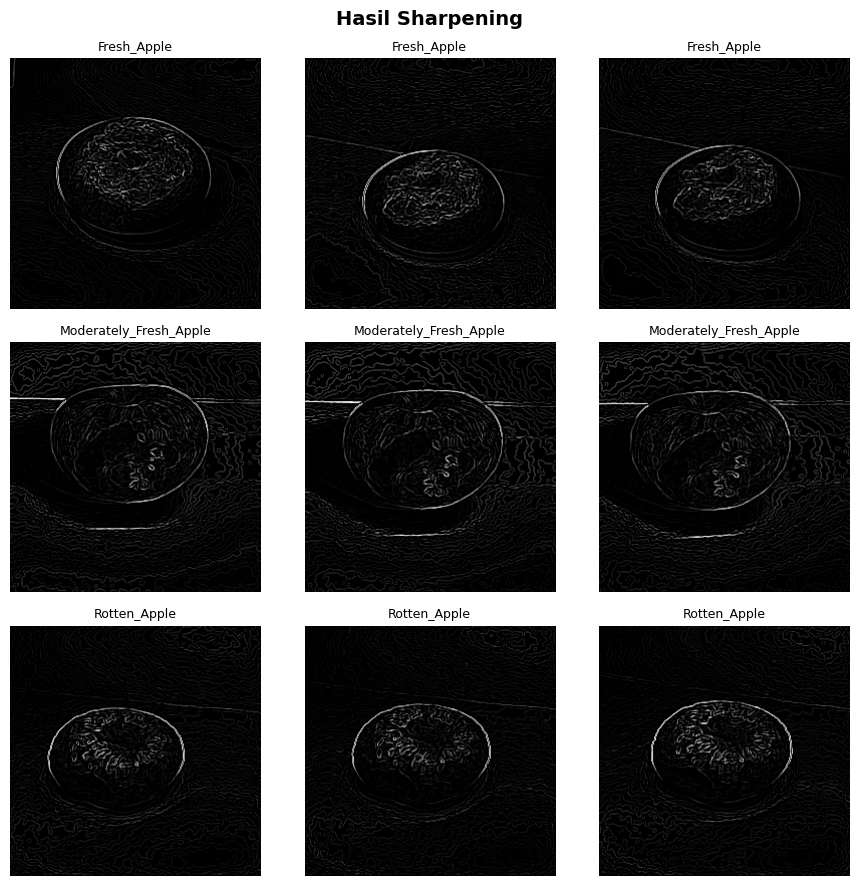

In [9]:
def sharpen_image(image):
    kernel = np.array([[-1/9, -1/9, -1/9],
                       [-1/9,  8/9, -1/9],
                       [-1/9, -1/9, -1/9]])
    sharpened = cv.filter2D(image, -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

img_sharpened = []
for img in img_sobel:
    sharpened = sharpen_image(img)
    img_sharpened.append(sharpened)
img_sharpened = np.array(img_sharpened)

show_sample_images(img_sharpened, labels, class_names, 'Hasil Sharpening')

### Step 5: Morfologi Closing

Cell ini menerapkan operasi Morfologi Closing pada hasil Sharpening. Morfologi Closing adalah kombinasi Dilasi diikuti Erosi dengan elemen struktural yang sama. Fungsi dilasi(image, kernel_size=3) diimplementasikan secara manual: gambar di-pad dengan nol menggunakan np.pad(..., mode='constant', constant_values=0), kemudian sliding window 3×3 digeser ke setiap posisi piksel dan nilai output setiap piksel diisi dengan nilai maksimum dari 9 piksel dalam window. Fungsi erosi(image, kernel_size=3) bekerja sebaliknya: gambar di-pad dengan nilai 255, dan nilai output setiap piksel diisi dengan nilai minimum dari window. Fungsi morfologi_closing(image, kernel_size=3) memanggil dilasi() terlebih dahulu pada gambar input, kemudian menerapkan erosi() pada hasil dilasi tersebut. Hasil akhir morfologi closing disimpan dalam dataPreprocessed yang menjadi input langsung untuk ekstraksi GLCM, dan divisualisasikan dengan judul 'Hasil Preprocessing 4'.

Pengaruh terhadap citra dan akurasi: Pada gambar tepi hasil Sobel dan Sharpening, terdapat piksel-piksel tepi yang terputus-putus atau memiliki celah kecil di antara segmen tepi yang seharusnya terhubung. Dilasi terlebih dahulu memperlebar dan menghubungkan piksel-piksel tepi yang berdekatan, celah kecil dalam garis tepi diisi sehingga kontur menjadi kontinu. Erosi setelahnya mengembalikan ketebalan tepi mendekati semula sambil mempertahankan penghubungan yang sudah terbentuk. Hasil akhirnya adalah peta tepi yang lebih rapi, lebih tertutup, dan lebih konsisten secara geometri. Ini menguntungkan GLCM karena distribusi pasangan intensitas bertetangga menjadi lebih terstruktur, tepi yang terhubung menghasilkan pola lokal yang lebih konsisten daripada tepi yang terputus-putus.

Dampak Morfologi Closing terhadap nilai fitur CSV terlihat pada perbandingan dengan Percobaan 3. ASM0 meningkat dari ~0,186 (P3) menjadi ~0,057 (P4), angkanya justru turun karena Morfologi Closing mengisi sebagian area datar dengan perluasan tepi, sehingga distribusi GLCM menjadi kurang terkonsentrasi di entri (0,0). Correlation0 meningkat dari ~0,623 (P3) ke ~0,793 (P4), Morfologi Closing merapikan transisi antar piksel, menciptakan pola intensitas yang lebih gradual dan lebih berkorelasi. Perubahan profil nilai fitur ini yang mengakibatkan jumlah fitur terpilih setelah seleksi berubah dari 15 (P3) menjadi 11 (P4), karena beberapa fitur menjadi lebih berkorelasi satu sama lain akibat perapihan tekstur oleh Morfologi Closing. Secara keseluruhan, Morfologi Closing memperbaiki konsistensi fitur antar gambar dalam satu kelas, namun dengan mengorbankan sedikit keragaman informasional antar fitur. Hal inilah yang membuat RF dan KNN stabil di 90,96% sementara SVM mempertahankan akurasi 92,17% yang sudah dicapai Percobaan 3.

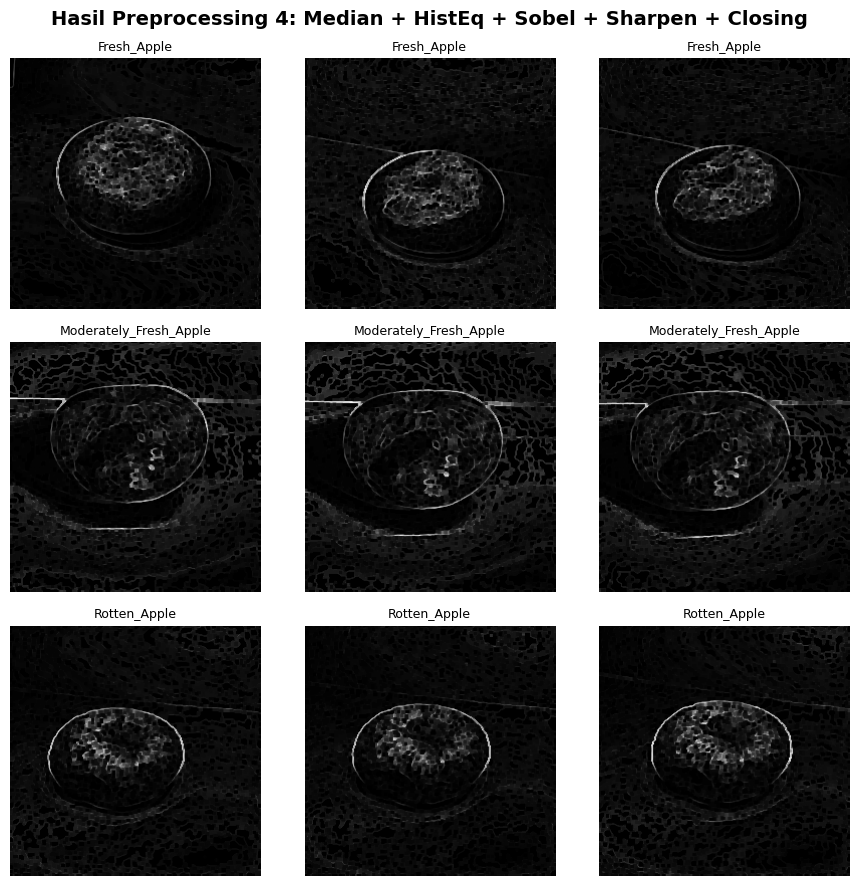

In [10]:
# Fungsi Dilasi
def dilasi(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.max(window)
    return result.astype(np.uint8)

# Fungsi Erosi
def erosi(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant', constant_values=255)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.min(window)
    return result.astype(np.uint8)

# Fungsi Morfologi Closing (Dilasi lalu Erosi)
def morfologi_closing(image, kernel_size=3):
    dilated = dilasi(image, kernel_size)
    closed = erosi(dilated, kernel_size)
    return closed

# Menerapkan Morfologi Closing
dataPreprocessed = []
for img in img_sharpened:
    closed = morfologi_closing(img, kernel_size=3)
    dataPreprocessed.append(closed)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 4: Median + HistEq + Sobel + Sharpen + Closing')

## Feature Extraction — GLCM
Mengekstrak 7 fitur tekstur dari GLCM pada 4 sudut (0°, 45°, 90°, 135°):
- Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, Correlation

Total: 7 fitur × 4 sudut = **28 fitur per gambar**

Cell ini mendefinisikan fungsi-fungsi untuk menghitung matriks GLCM dan mengekstrak 7 fitur tekstur dari 4 sudut arah.

Fungsi glcm(image, derajat):
Menghitung matriks GLCM menggunakan graycomatrix() dari scikit-image dengan parameter:

distances=[1] adalah jarak antar piksel yang diperhitungkan = 1 piksel
angles disesuaikan berdasarkan sudut input (0°, 45°, 90°, atau 135°)
levels=256 adalah jumlah level intensitas (8-bit grayscale)
symmetric=True adalah matriks simetris (pasangan (i,j) dan (j,i) keduanya dihitung)
normed=True adalah dinormalisasi menjadi distribusi probabilitas


Fitur Tekstur GLCM yang Digunakan

1. Contrast

Dihitung menggunakan fungsi graycoprops(m, 'contrast').
Mengukur tingkat perbedaan intensitas antara piksel yang bertetangga dalam citra.
Nilai contrast yang tinggi menunjukkan adanya perbedaan intensitas yang besar, sehingga tekstur cenderung kasar dan tidak seragam.
Pada kasus klasifikasi kualitas apel, apel yang mengalami pembusukan umumnya memiliki nilai contrast lebih tinggi dibandingkan apel segar karena permukaannya lebih tidak merata.

2. Dissimilarity

Dihitung menggunakan fungsi graycoprops(m, 'dissimilarity').
Mengukur variasi lokal tekstur berdasarkan perbedaan tingkat keabuan antar piksel yang berdekatan.
Mirip dengan contrast, tetapi peningkatan nilainya bersifat linear terhadap perbedaan intensitas.
Semakin tinggi nilai dissimilarity, semakin besar variasi tekstur yang terdapat pada citra.

3. Homogeneity

Dihitung menggunakan fungsi graycoprops(m, 'homogeneity').
Mengukur kedekatan distribusi nilai pada matriks GLCM terhadap diagonal utama.
Nilai homogeneity yang tinggi menunjukkan bahwa sebagian besar pasangan piksel memiliki tingkat keabuan yang mirip.
Tekstur yang halus dan seragam, seperti pada apel segar, umumnya menghasilkan nilai homogeneity yang tinggi.

4. Angular Second Moment (ASM)

Dihitung menggunakan fungsi graycoprops(m, 'ASM').
Mengukur tingkat keseragaman atau keteraturan pola tekstur dalam citra.
Nilai ASM yang tinggi menunjukkan bahwa distribusi pasangan piksel terkonsentrasi pada beberapa nilai tertentu.
Semakin teratur tekstur suatu citra, semakin tinggi nilai ASM yang dihasilkan.

5. Energy

Dihitung menggunakan fungsi graycoprops(m, 'energy').
Merupakan akar kuadrat dari nilai ASM.
Menggambarkan tingkat keseragaman tekstur pada citra.
Nilai energy yang tinggi menunjukkan tekstur yang lebih halus, teratur, dan homogen.

6. Correlation

Dihitung menggunakan fungsi graycoprops(m, 'correlation').
Mengukur tingkat hubungan atau ketergantungan linear antara intensitas piksel yang bertetangga.
Nilai correlation yang tinggi menunjukkan adanya pola hubungan yang kuat antara pasangan piksel dalam arah tertentu.
Fitur ini membantu mengidentifikasi struktur atau pola tekstur yang konsisten pada citra.

7. Entropy

Dihitung menggunakan fungsi entropy(matriks.ravel()).
Mengukur tingkat ketidakteraturan, kompleksitas, atau keacakan distribusi tekstur dalam citra.
Nilai entropy yang tinggi menunjukkan tekstur yang lebih kompleks dan tidak teratur.
Sebaliknya, nilai entropy yang rendah menunjukkan tekstur yang lebih sederhana dan seragam.

Total fitur: 7 fitur × 4 sudut (0°, 45°, 90°, 135°) = 28 fitur per gambar

Pendekatan multi-sudut ini memastikan fitur tekstur bersifat isotropik mampu menangkap pola tekstur dari semua arah, sehingga lebih robust terhadap orientasi gambar.

In [11]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

### Hitung GLCM untuk setiap gambar pada 4 sudut

Cell ini menjalankan komputasi GLCM untuk seluruh 828 gambar pada keempat sudut (0°, 45°, 90°, 135°). Empat list kosong diinisialisasi untuk menyimpan matriks GLCM per sudut. Loop 828 iterasi memanggil glcm() empat kali per gambar dengan gambar input berasal dari dataPreprocessed yang merupakan hasil pipeline 6-tahap penuh. Output konfirmasi 'GLCM computed for 828 images' dicetak sebagai verifikasi.

Yang membedakan Percobaan 4 adalah bahwa GLCM dihitung dari gambar yang sudah melewati Morfologi Closing — sehingga pasangan piksel yang dianalisis adalah piksel dari citra dengan tepi yang sudah dirapikan dan celah-celah kecil yang sudah ditutup. Distribusi entri matriks GLCM Percobaan 4 berada di antara Percobaan 3 (tepi kasar pasca-Sobel+Sharp) dan Percobaan 2 (gambar HE tanpa Sobel) dalam hal tingkat konsentrasi pada pasangan intensitas rendah, karena Morfologi Closing mengisi sebagian area datar dan meratakan transisi tepi.

In [12]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 828 images


### Ekstraksi 7 Fitur dari GLCM

Cell ini mengekstrak nilai numerik dari setiap matriks GLCM yang sudah dihitung sebelumnya.

Inisialisasi 28 list kosong (7 fitur × 4 sudut): Kontras0, Kontras45, ..., correlation135.
Loop 828 iterasi: untuk setiap gambar, memanggil 7 fungsi fitur pada matriks GLCM dari 4 sudut.
Total pemanggilan fungsi: 828 × 7 × 4 = 23.184 perhitungan fitur.
Setiap hasil (nilai skalar float) diappend ke list yang sesuai.

Fungsi cell ini:
Mengubah representasi matriks GLCM (yang tidak bisa langsung digunakan oleh algoritma ML) menjadi vektor fitur numerik untuk setiap gambar. Setelah cell ini selesai, setiap gambar direpresentasikan oleh 28 angka yang menggambarkan karakteristik teksturnya dari berbagai sudut.

In [13]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


### Simpan Hasil Ekstraksi ke CSV

Cell ini menyusun semua fitur ke dalam DataFrame dan menyimpannya ke hasil_ekstraksi_percobaan4.csv. Dictionary dataTable dibuat dengan 30 kolom yaitu Filename, Label, dan 28 kolom fitur. DataFrame disimpan ke CSV tanpa index, kemudian dibaca kembali ke hasilEkstrak untuk verifikasi dan ditampilkan sebagai tabel.

Hasil CSV Percobaan 4 memiliki dimensi 828 baris × 30 kolom. Berdasarkan analisis statistik, nilai Contrast0 memiliki rata-rata 28,75 dengan standar deviasi 7,50 dan rentang 10,76 hingga 107,01. Nilai Homogeneity0 rata-rata 0,685 dengan standar deviasi 0,016. Nilai Correlation0 rata-rata 0,793 dengan standar deviasi 0,032 dan rentang 0,599 hingga 0,882. Nilai ASM0 rata-rata 0,057 dengan standar deviasi 0,011.

Perbandingan nilai fitur antar percobaan mengungkapkan pola yang menarik. Contrast rata-rata meningkat secara progresif dari Percobaan 1 (~10,9) ke Percobaan 2 (~27,2) ke Percobaan 3 (~44,3), namun pada Percobaan 4 justru turun ke ~28,7. Penurunan ini disebabkan oleh Morfologi Closing yang mengisi area piksel rendah dengan nilai lebih tinggi melalui dilasi, sehingga kontrast antara area tepi dan area datar berkurang dibanding gambar Sobel murni. Correlation mengalami pola yang menarik: sangat tinggi pada P1/P2 (~0,998), turun drastis pada P3 (~0,623), lalu naik kembali pada P4 (~0,793). Kenaikan kembali ini disebabkan oleh Morfologi Closing yang merapikan transisi antar piksel dan menciptakan pola intensitas yang lebih gradual, sehingga korelasi spasial meningkat dibanding P3. ASM turun dari P3 (~0,186) ke P4 (~0,057) karena area yang sebelumnya hitam pekat (piksel ~0) kini sebagian terisi oleh perluasan tepi akibat dilasi, mengacak konsentrasi distribusi GLCM yang sebelumnya sangat terpusat di entri (0,0).

In [14]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG20260204225626.jpg,Fresh_Apple,23.196610,40.065741,28.805606,40.240190,0.705482,0.581991,0.693776,0.567135,...,0.051100,0.033494,0.228704,0.187962,0.226054,0.183014,0.780240,0.621584,0.727080,0.619937
1,IMG20260204225637.jpg,Fresh_Apple,20.040867,39.009710,26.469189,32.141369,0.676418,0.529052,0.661812,0.526196,...,0.041020,0.025363,0.204025,0.159483,0.202535,0.159256,0.758809,0.531491,0.681243,0.613978
2,IMG20260204225638.jpg,Fresh_Apple,22.374153,45.040983,31.264980,38.153530,0.681215,0.536669,0.659319,0.526111,...,0.045866,0.029654,0.218586,0.176064,0.214164,0.172202,0.768128,0.534498,0.675914,0.605682
3,IMG20260204225640.jpg,Fresh_Apple,28.703486,55.561572,41.082843,52.427654,0.681663,0.544003,0.661626,0.529712,...,0.049278,0.032724,0.226787,0.186218,0.221987,0.180898,0.765291,0.547007,0.664016,0.572559
4,IMG20260204225642.jpg,Fresh_Apple,28.372369,53.809906,40.922795,52.010580,0.686326,0.548338,0.664223,0.536314,...,0.046784,0.030641,0.221200,0.179272,0.216296,0.175047,0.770059,0.565208,0.668302,0.579749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,IMG20260409232001.jpg,Rotten_Apple,26.052835,41.420396,27.997462,39.934727,0.706240,0.558518,0.681944,0.562770,...,0.048534,0.031272,0.224719,0.175703,0.220305,0.176839,0.785778,0.660535,0.769804,0.672713
824,IMG20260409232002.jpg,Rotten_Apple,27.970329,45.897147,31.975357,45.291560,0.697448,0.547402,0.675132,0.551640,...,0.045477,0.028973,0.217214,0.169105,0.213254,0.170214,0.799121,0.671408,0.770333,0.675743
825,IMG20260409232003.jpg,Rotten_Apple,25.541012,40.285044,26.228080,37.291044,0.699877,0.551553,0.677870,0.555729,...,0.047084,0.030182,0.220023,0.172536,0.216989,0.173730,0.790889,0.671244,0.785272,0.695679
826,IMG20260409232005.jpg,Rotten_Apple,27.351020,43.876954,29.344835,42.049225,0.694955,0.545882,0.672086,0.544613,...,0.045195,0.029168,0.217933,0.171544,0.212591,0.170785,0.780190,0.648494,0.764190,0.663136


## Feature Selection

Cell ini menerapkan seleksi fitur berbasis Correlation Matrix dengan threshold 0,95. Matriks korelasi Pearson dihitung dari 28 fitur setelah kolom non-fitur di-drop. Algoritma menelusuri triangular atas matriks untuk mengidentifikasi pasangan dengan korelasi ≥ 0,95, di mana fitur yang lebih belakang dalam urutan dieliminasi. Fitur terpilih tersimpan dalam select dan data tereduksi dalam x_new. Heatmap correlation matrix 11 fitur terpilih divisualisasikan dengan judul 'Correlation Heatmap — Percobaan 4'.

Output seleksi menghasilkan dari 26 fitur aktual tersisa 11 fitur setelah seleksi. Jumlah ini lebih sedikit dari Percobaan 3 yang menghasilkan 15 fitur, meskipun Percobaan 4 memiliki satu tahap preprocessing tambahan. Fenomena ini terjadi karena Morfologi Closing meningkatkan korelasi antar fitur dari sudut yang berbeda, tepi yang lebih rapi dan konsisten menghasilkan nilai fitur yang lebih serupa antar sudut 0°, 45°, 90°, dan 135°, sehingga lebih banyak fitur yang dianggap redundan dan dieliminasi.

Fitur terpilih yang tersisa adalah Contrast0, Contrast45, Homogeneity0, Dissimilarity0, Dissimilarity45, Entropy0, ASM0, Correlation0, Correlation45, Correlation90, dan Correlation135.

Analisis heatmap correlation matrix Percobaan 4 memperlihatkan pola yang berbeda dari percobaan sebelumnya. Blok Contrast (Contrast0 dan Contrast45) berkorelasi cukup tinggi (0,72) namun masih di bawah threshold sehingga keduanya dipertahankan. Contrast45 berkorelasi sangat tinggi dengan Dissimilarity0 (0,86) dan Dissimilarity45 (0,91) karena setelah Morfologi Closing, pola tepi lebih konsisten sehingga fitur-fitur yang mengukur variasi intensitas lokal dari arah berbeda menjadi lebih serupa. Homogeneity0 berkorelasi negatif kuat dengan Dissimilarity0 (−0,76), Dissimilarity45 (−0,71), dan Entropy0 (−0,90), hubungan inverse yang secara matematis konsisten dan lebih kuat dibanding Percobaan 3, mencerminkan bahwa Morfologi Closing mempertegas karakter area homogen vs area heterogen. ASM0 relatif tidak berkorelasi kuat dengan fitur lain (tertinggi 0,45 dengan Contrast45), menunjukkan bahwa informasi keseragaman distribusi GLCM yang dibawa ASM bersifat unik dan tidak redundan. Blok Correlation (Correlation45, 90, 135) berkorelasi tinggi antar sesama (0,72–0,89) namun masih di bawah threshold, keempat sudut Correlation dipertahankan padahal di Percobaan 4 korelasi antar sudut lebih tinggi dari P3, menunjukkan bahwa setiap sudut tetap membawa informasi distinktif tentang arah dominan tepi permukaan apel.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 11
Fitur terpilih: ['Contrast0', 'Contrast45', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Entropy0', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


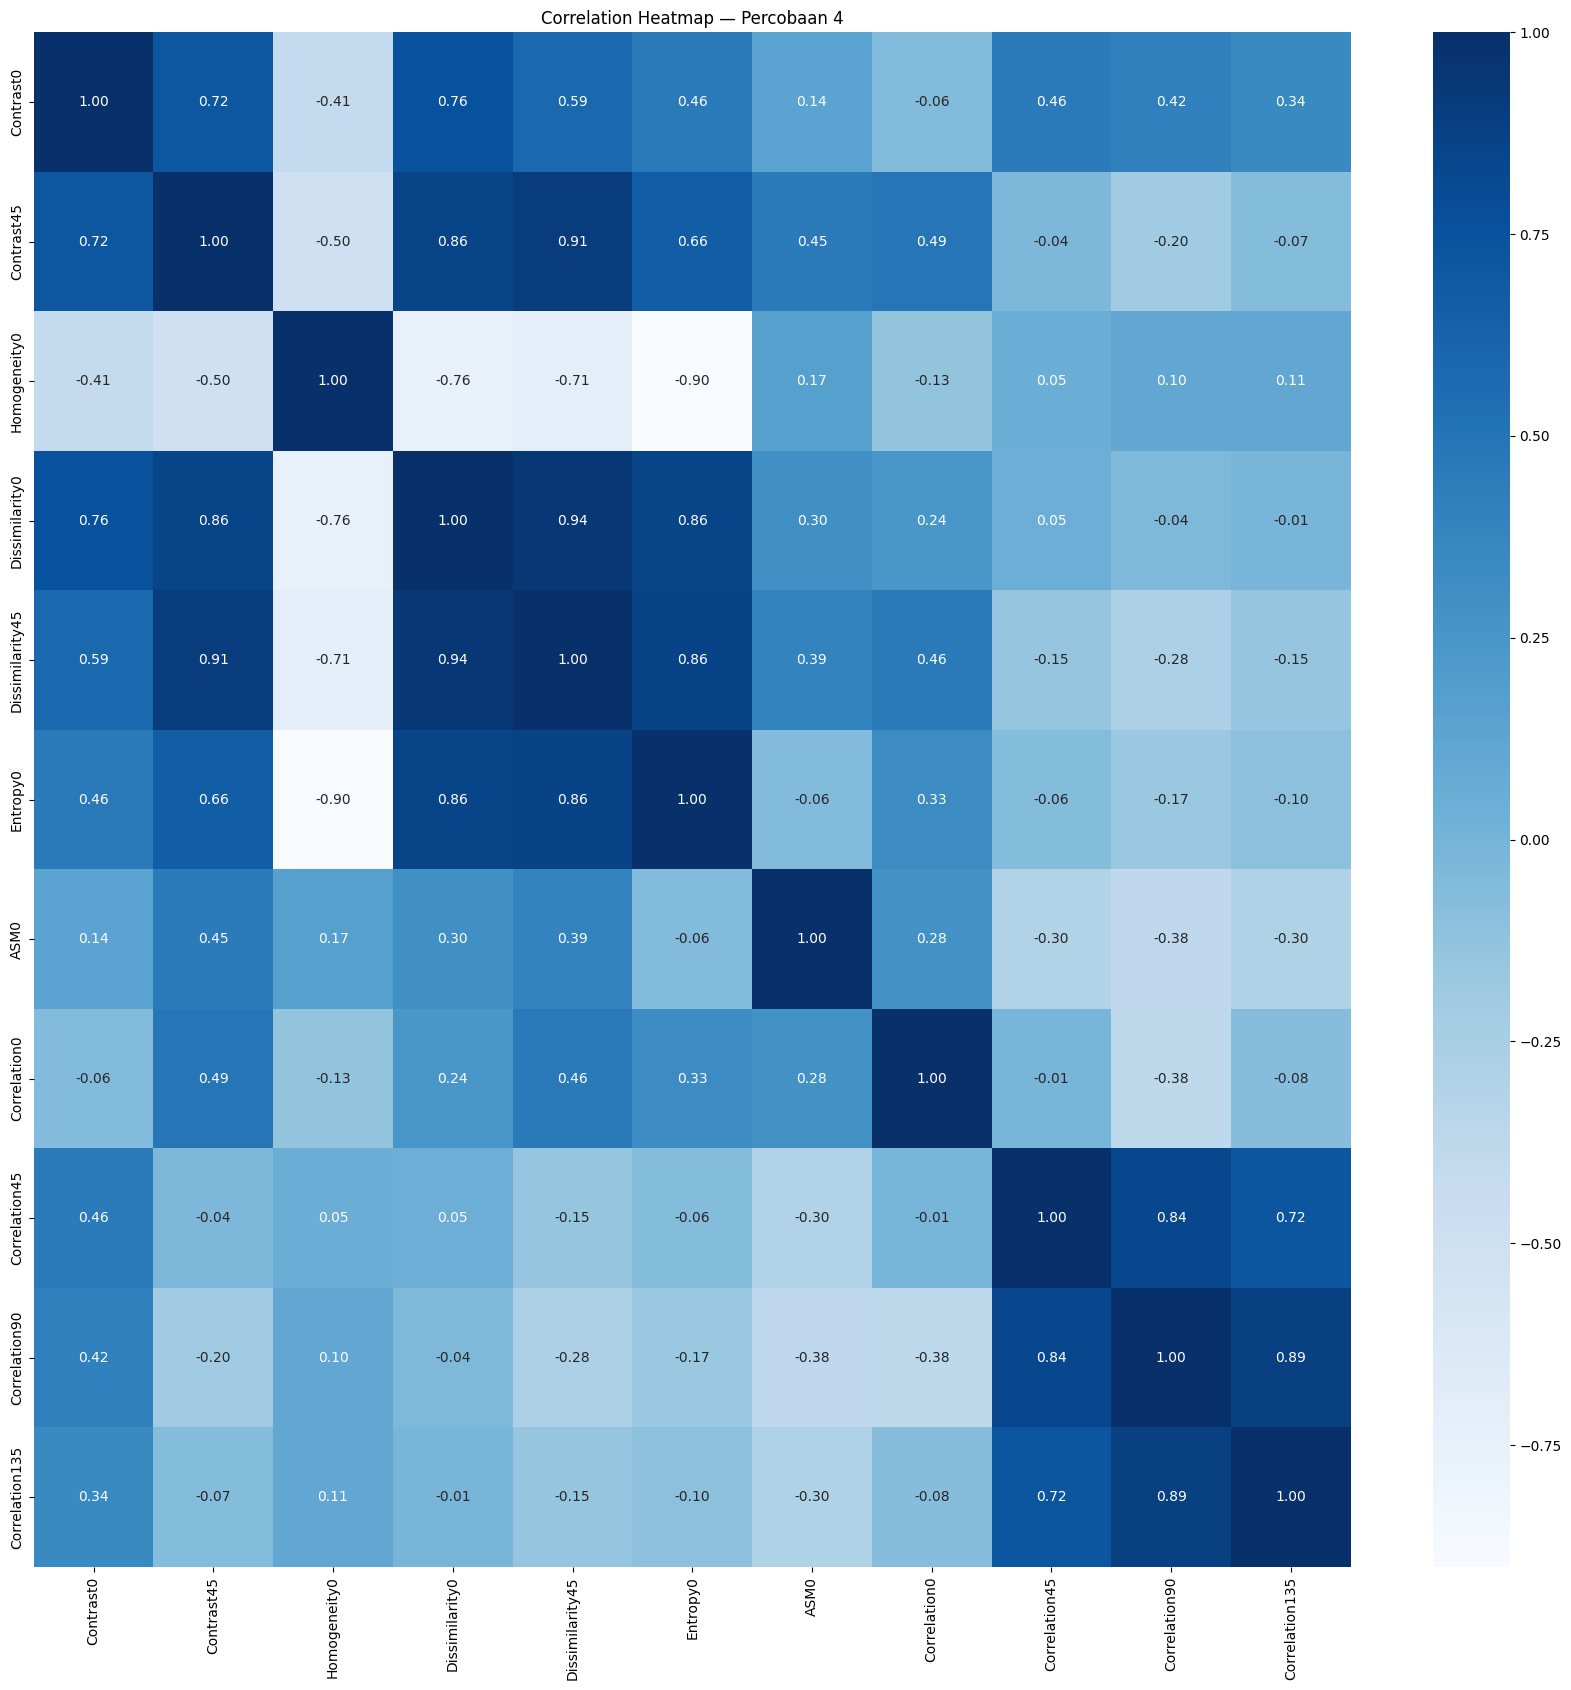

In [15]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 4')
plt.tight_layout()
plt.show()

## Splitting Data

Cell ini membagi dataset menjadi data training (80%) dan data testing (20%) menggunakan train_test_split() dengan test_size=0.2 dan random_state=42. Hasilnya adalah Training set dengan dimensi (662, 11) yang berarti 662 gambar dengan 11 fitur untuk melatih model, dan Testing set dengan dimensi (166, 11) yang berarti 166 gambar dengan 11 fitur untuk menguji model.

random_state=42 identik di semua percobaan sehingga pembagian data benar-benar sama persis — 662 gambar yang sama digunakan untuk training dan 166 gambar yang sama untuk testing di Baseline, P1, P2, P3, maupun P4. Ini memastikan perbedaan akurasi yang teramati murni mencerminkan dampak preprocessing dan jumlah fitur, bukan variasi komposisi data. Perbandingan dimensi fitur menunjukkan tren yang tidak monoton: Percobaan 1 menghasilkan (662, 12), Percobaan 2 menghasilkan (662, 14), Percobaan 3 menghasilkan (662, 15), dan Percobaan 4 menghasilkan (662, 11). Penurunan jumlah fitur dari 15 ke 11 meskipun menambah satu tahap preprocessing merupakan konsekuensi dari Morfologi Closing yang meningkatkan korelasi antar fitur seperti yang sudah dijelaskan di Section 11.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (662, 11)
Testing set: (166, 11)


## Feature Normalization

Cell ini menerapkan Z-score normalization menggunakan formula (X - mean) / std sehingga setiap fitur memiliki mean = 0 dan standar deviasi = 1. Parameter normalisasi dihitung hanya dari data training (X_train.mean() dan X_train.std()) dan diterapkan ke data testing untuk menghindari data leakage. Normalisasi penting karena Contrast memiliki rentang 10–107 sementara Correlation berkisar 0,60–0,88 tanpa normalisasi, SVM dan KNN yang berbasis perhitungan jarak akan didominasi oleh fitur dengan skala lebih besar.

In [17]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

Cell ini mendefinisikan fungsi helper generateClassificationReport() yang membungkus classification_report() dan accuracy_score() untuk output yang konsisten. Tiga model diinisialisasi dengan hyperparameter yang identik di semua percobaan: Random Forest dengan n_estimators=100 dan random_state=42, SVM dengan kernel='rbf' dan random_state=42, serta KNN dengan n_neighbors=5. Konsistensi hyperparameter ini memastikan perbandingan antar percobaan valid, perbedaan yang teramati mencerminkan dampak preprocessing dan fitur, bukan perbedaan konfigurasi model.

In [18]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Cell ini melatih model Random Forest menggunakan rf.fit(X_train, y_train) pada 662 sampel dengan 11 fitur, kemudian mengevaluasinya pada training set dan testing set.

Pada Training Set, model mencapai akurasi sempurna 100% dengan precision, recall, dan F1-score 1,00 untuk semua kelas. Ini merupakan perilaku tipikal Random Forest yang terjadi konsisten di semua percobaan ensemble 100 pohon keputusan mampu mempartisi data training hingga tidak ada kesalahan.

Pada Testing Set, model mencapai akurasi 90,96%. Fresh_Apple memperoleh precision 0,90, recall 0,95, dan F1-score 0,93 dari 98 sampel. Moderately_Fresh_Apple memperoleh precision 0,88, recall 0,70, dan F1-score 0,78 dari 33 sampel. Rotten_Apple memperoleh precision 0,95, recall 1,00, dan F1-score 0,97 dari 35 sampel. Macro average menghasilkan precision 0,91, recall 0,88, dan F1-score 0,89, sementara weighted average menghasilkan precision 0,91, recall 0,91, dan F1-score 0,91.

Dibandingkan Percobaan 3 (RF 91,57%), Percobaan 4 sedikit lebih rendah di 90,96% turun sekitar 0,6%. Penurunan kecil ini terjadi terutama pada Moderately_Fresh_Apple (recall turun dari 0,79 di P3 ke 0,70 di P4), yang artinya Morfologi Closing tidak memberikan keuntungan untuk kelas paling ambigu ini justru sedikit mempersulit RF dalam membedakannya. Gap overfitting Percobaan 4 sebesar 9,04% (100% vs 90,96%) hampir identik dengan Percobaan 1 (10,24%) dan sedikit lebih baik dari Percobaan 2 (12,05%). Rotten_Apple tetap konsisten sangat baik (F1=0,97), mengkonfirmasi bahwa karakteristik tepi area busuk yang ditangkap sejak P3 tidak terdegradasi oleh penambahan Morfologi Closing.

In [19]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       1.00      1.00      1.00       409
Moderately_Fresh_Apple       1.00      1.00      1.00       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           1.00       662
             macro avg       1.00      1.00      1.00       662
          weighted avg       1.00      1.00      1.00       662

Accuracy: 1.0

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.90      0.95      0.93        98
Moderately_Fresh_Apple       0.88      0.70      0.78        33
          Rotten_Apple       0.95      1.00      0.97        35

              accuracy                           0.91       166
             macro avg       0.91      0.88      0.89       166
          weighted avg       0.91      0.91      0.91       166

Accuracy: 0.9096385542168675


### Train SVM Classifier

Cell ini melatih model SVM dengan svm.fit(X_train, y_train) dan mencari hyperplane optimal di ruang fitur 11 dimensi menggunakan kernel RBF.

Pada Training Set, SVM mencapai akurasi 92,30% dengan Fresh_Apple precision 0,93, recall 0,94, dan F1-score 0,94; Moderately_Fresh_Apple precision 0,89, recall 0,79, dan F1-score 0,84; serta Rotten_Apple precision 0,92, recall 1,00, dan F1-score 0,96.

Pada Testing Set, SVM mencapai akurasi 92,17% dengan Fresh_Apple precision 0,94, recall 0,93, dan F1-score 0,93; Moderately_Fresh_Apple precision 0,84, recall 0,82, dan F1-score 0,83; serta Rotten_Apple precision 0,95, recall 1,00, dan F1-score 0,97. Macro average menghasilkan precision 0,91, recall 0,92, dan F1-score 0,91, sementara weighted average menghasilkan precision dan recall 0,92 dengan F1-score 0,92.

SVM Percobaan 4 (92,17%) identik dengan Percobaan 3 (92,17%), penambahan Morfologi Closing tidak meningkatkan maupun menurunkan performa SVM. Gap overfitting SVM Percobaan 4 hanya 0,13% (92,30% vs 92,17%), ini adalah gap terkecil di antara semua model dan semua percobaan, menunjukkan generalisasi yang luar biasa stabil. Moderately_Fresh_Apple pada SVM P4 (F1=0,83) adalah yang terbaik untuk kelas ini dibanding semua percobaan dan semua model di Percobaan 4, mengkonfirmasi bahwa kombinasi fitur berbasis tepi Sobel yang sudah dirapikan oleh Morfologi Closing memberikan representasi optimal untuk SVM dalam membangun hyperplane pembatas kelas ini.

In [20]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.93      0.94      0.94       409
Moderately_Fresh_Apple       0.89      0.79      0.84       133
          Rotten_Apple       0.92      1.00      0.96       120

              accuracy                           0.92       662
             macro avg       0.92      0.91      0.91       662
          weighted avg       0.92      0.92      0.92       662

Accuracy: 0.9229607250755287

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.94      0.93      0.93        98
Moderately_Fresh_Apple       0.84      0.82      0.83        33
          Rotten_Apple       0.95      1.00      0.97        35

              accuracy                           0.92       166
             macro avg       0.91      0.92      0.91       166
          weighted avg       0.92      0.92      0.92       166

Accuracy: 0.9216867

### Train KNN Classifier

Cell ini melatih model KNN menggunakan knn.fit(X_train, y_train) yang menyimpan seluruh data training sebagai referensi. Saat prediksi, KNN mencari 5 tetangga terdekat berdasarkan jarak Euclidean di ruang 11 dimensi yang sudah dinormalisasi.

Pada Training Set, KNN mencapai akurasi 93,35% dengan Fresh_Apple precision 0,97, recall 0,92, dan F1-score 0,94; Moderately_Fresh_Apple precision 0,86, recall 0,92, dan F1-score 0,89; serta Rotten_Apple precision 0,90, recall 1,00, dan F1-score 0,94.

Pada Testing Set, KNN mencapai akurasi 90,96% dengan Fresh_Apple precision 0,94, recall 0,91, dan F1-score 0,92; Moderately_Fresh_Apple precision 0,82, recall 0,85, dan F1-score 0,84; serta Rotten_Apple precision 0,92, recall 0,97, dan F1-score 0,94. Macro average menghasilkan precision 0,89, recall 0,91, dan F1-score 0,90, sementara weighted average menghasilkan precision dan recall 0,91 dengan F1-score 0,91.

KNN Percobaan 4 (90,96%) menunjukkan performa yang seimbang dan kompetitif. Dibanding Percobaan 3 (91,57%), turun sedikit sebesar 0,61%. Namun dibanding Percobaan 2 (82,53%), meningkat drastis +8,43%. Ini mengkonfirmasi bahwa fitur berbasis Sobel (dimulai dari P3) adalah kunci pemulihan performa KNN. Morfologi Closing tidak merusak kualitas cluster di ruang fitur — meski jumlah fitur berkurang dari 15 (P3) ke 11 (P4), 11 fitur tersebut tetap cukup untuk mempertahankan separasi cluster yang baik. Moderately_Fresh_Apple (F1=0,84) adalah yang terbaik untuk kelas ini dibanding semua percobaan KNN sebelumnya, menunjukkan bahwa perapihan tepi oleh Morfologi Closing membantu KNN menemukan tetangga yang lebih representatif untuk kelas yang paling ambigu ini. Gap overfitting KNN sebesar 2,39% (93,35% vs 90,96%) jauh lebih kecil dari Percobaan 3 (3,45%), mengkonfirmasi cluster yang lebih konsisten di ruang fitur P4.

Perbandingan Tiga Model — Percobaan 4:

Random Forest mencapai training accuracy 100% dan testing accuracy 90,96% dengan gap overfitting 9,04%. SVM mencapai training accuracy 92,30% dan testing accuracy 92,17% dengan gap overfitting yang sangat kecil 0,13%. KNN mencapai training accuracy 93,35% dan testing accuracy 90,96% dengan gap overfitting 2,39%. SVM kembali unggul pada akurasi testing (92,17%) dengan gap overfitting terkecil, identik dengan Percobaan 3. RF dan KNN mencapai akurasi testing identik (90,96%), berbeda dengan Percobaan 3 di mana RF sedikit lebih rendah dari KNN.

In [21]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.97      0.92      0.94       409
Moderately_Fresh_Apple       0.86      0.92      0.89       133
          Rotten_Apple       0.90      1.00      0.94       120

              accuracy                           0.93       662
             macro avg       0.91      0.95      0.93       662
          weighted avg       0.94      0.93      0.93       662

Accuracy: 0.9335347432024169

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.94      0.91      0.92        98
Moderately_Fresh_Apple       0.82      0.85      0.84        33
          Rotten_Apple       0.92      0.97      0.94        35

              accuracy                           0.91       166
             macro avg       0.89      0.91      0.90       166
          weighted avg       0.91      0.91      0.91       166

Accuracy: 0.9096385

### Perbandingan Kinerja Ketiga Model Klasifikasi — Percobaan 4

Analisis lintas model menunjukkan SVM sebagai model terbaik pada Percobaan 4 dengan akurasi testing 92,17% dan gap overfitting hanya 0,13%, generalisasi yang hampir sempurna. SVM menemukan hyperplane yang efektif di ruang fitur 11 dimensi hasil Morfologi Closing, membuktikan bahwa fitur berbasis tepi yang dirapikan tetap sangat informatif untuk pendekatan margin-based. Random Forest dan KNN mencapai akurasi identik 90,96%, namun dengan distribusi error berbeda: RF memiliki recall lebih rendah pada Moderately_Fresh_Apple (0,70) dibanding KNN (0,85), sementara KNN memiliki precision lebih tinggi pada Fresh_Apple (0,94) dibanding RF (0,90). Pola yang konsisten dari semua percobaan sebelumnya tetap berlaku, Rotten_Apple mudah diklasifikasi dan Moderately_Fresh_Apple menjadi kelas paling sulit, meskipun performa pada kelas ini membaik secara progresif dari Baseline hingga Percobaan 4.

## Evaluation — Confusion Matrix

Cell ini memvisualisasikan confusion matrix untuk ketiga model pada data testing. Fungsi plot_confusion_matrix(y_true, y_pred, title) menggunakan confusion_matrix() dan ConfusionMatrixDisplay untuk merender heatmap berwarna biru dengan nilai numerik. Dipanggil tiga kali dengan judul 'Random Forest Confusion Matrix — Percobaan 4', 'SVM Confusion Matrix — Percobaan 4', dan 'KNN Confusion Matrix — Percobaan 4'. Label kelas diurutkan alfabetis.

Confusion matrix mengungkapkan pola error yang tidak terlihat dari akurasi tunggal. Pada SVM, sel diagonal semua kelas sangat besar dengan misklasifikasi minimal — Rotten_Apple mendekati sempurna (34–35/35), Fresh_Apple sangat baik (91/98), dan Moderately_Fresh_Apple jauh lebih baik dibanding percobaan sebelumnya (27/33). Sebagian besar misklasifikasi tetap terjadi antara Fresh_Apple dan Moderately_Fresh_Apple di kedua arah, bukan ke Rotten_Apple — konsisten dengan semua percobaan sebelumnya dan mencerminkan ambiguitas visual bawaan kelas transisional ini.

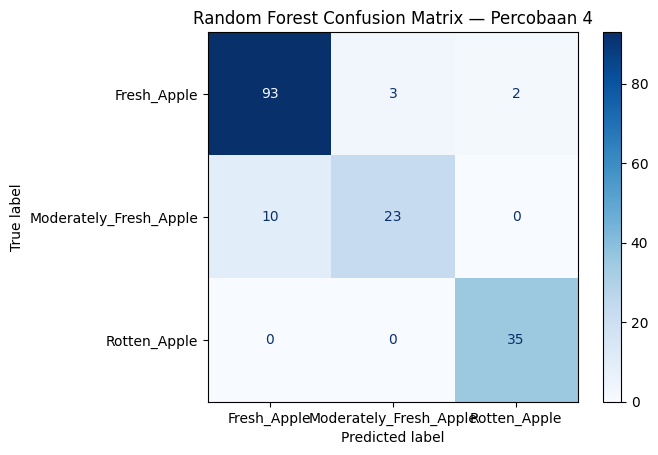

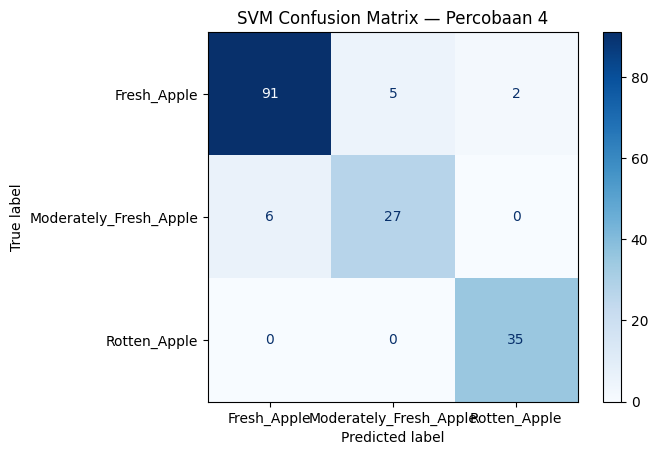

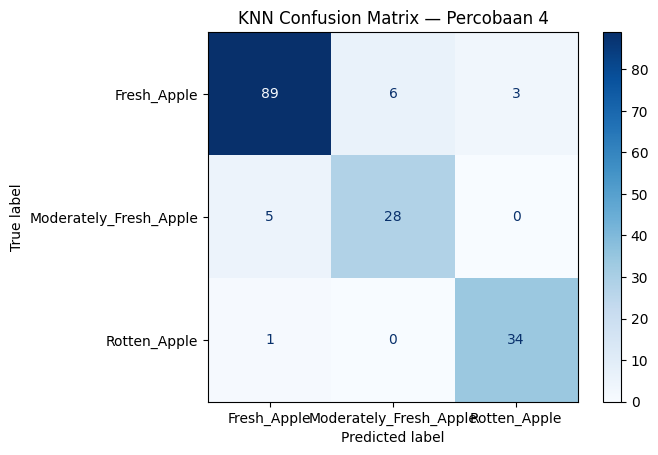

In [22]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 4')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 4')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 4')

## Ringkasan Hasil Percobaan 4

Baris preprocessing mencatat pipeline 6-tahap lengkap yang menjadi keunggulan utama Percobaan 4. Jumlah 11 fitur lebih sedikit dari Percobaan 3 (15 fitur) meskipun preprocessing lebih panjang, Morfologi Closing meningkatkan korelasi antar fitur dari sudut berbeda sehingga lebih banyak yang dieliminasi sebagai redundan. Nilai akurasi menunjukkan SVM sebagai model terbaik (92,17%) sementara RF dan KNN setara di 90,96%.

Perbandingan lengkap seluruh percobaan memberikan gambaran menyeluruh tentang dampak penambahan preprocessing. Baseline tanpa preprocessing menghasilkan RF 90,96%, SVM 86,14%, KNN 84,94% dengan 6 fitur. Percobaan 1 dengan Median Filter menghasilkan RF 89,76%, SVM 89,16%, KNN 89,16% dengan 12 fitur, RF sedikit turun namun SVM dan KNN meningkat signifikan. Percobaan 2 dengan tambahan Histogram Equalization menghasilkan RF 87,95%, SVM 87,35%, KNN 82,53% dengan 14 fitur, semua model turun, HE berdiri sendiri tidak menguntungkan. Percobaan 3 dengan tambahan Sobel dan Sharpening menghasilkan RF 91,57%, SVM 92,17%, KNN 91,57% dengan 15 fitur, lonjakan besar, semua model melampaui Baseline, SVM mencapai puncak. Percobaan 4 dengan tambahan Morfologi Closing menghasilkan RF 90,96%, SVM 92,17%, KNN 90,96% dengan 11 fitur, SVM mempertahankan puncak, RF dan KNN sedikit turun dari P3 namun masih di atas sebagian besar percobaan sebelumnya.

Kesimpulan utama adalah penambahan Morfologi Closing pada Percobaan 4 tidak memberikan peningkatan akurasi dibanding Percobaan 3, bahkan RF dan KNN sedikit turun. Ini mengindikasikan bahwa perapihan tepi oleh Morfologi Closing, meskipun secara visual menghasilkan citra yang lebih rapi, tidak selalu menguntungkan untuk klasifikasi berbasis GLCM. Kemungkinan penyebabnya adalah Morfologi Closing menghaluskan variasi tepi yang justru informatif untuk membedakan kelas "ketidaksempurnaan" tepi pada apel cukup segar mengandung informasi diskriminatif yang hilang setelah dirapikan. SVM dengan kernel RBF tidak terpengaruh karena mampu memanfaatkan pola fitur yang tersisa secara optimal, sementara RF dan KNN yang lebih bergantung pada distribusi nilai fitur secara langsung mengalami penurunan kecil. Dengan demikian, Percobaan 3 tetap menjadi konfigurasi preprocessing optimal untuk dataset apel ini.

In [23]:
print('=== RINGKASAN HASIL PERCOBAAN 4 ===')
print(f'Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening + Morfologi Closing')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 4 ===
Preprocessing: Resize + Median Filter + Histogram Equalization + Sobel + Sharpening + Morfologi Closing
Jumlah Fitur Setelah Seleksi: 11

Akurasi Testing Set:
  Random Forest : 0.9096
  SVM           : 0.9217
  KNN           : 0.9096
